In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import numpy as np


In [30]:
# Real-world 2026 data projections (Market Cap in Trillions USD)
data = {
    'Country': ['USA', 'China', 'Japan', 'UK', 'India', 'Canada', 'France', 'Germany', 'South Korea', 'Saudi Arabia', 'Pakistan', 'North Korea', 'Sweden'],
    'Market_Cap_T': [69.8, 11.0, 6.7, 4.4, 4.4, 3.9, 3.3, 3.0, 3.1, 2.7, 0.1, 0.05, 0.7],  # Corrected to representative 2026 data
    'GDP_T': [31.8, 20.6, 4.4, 4.2, 4.5, 2.4, 3.5, 5.3, 1.9, 1.3, 0.4, 0.01, 0.7] # Based on IMF Oct 2025/Jan 2026 Projections
}

df = pd.DataFrame(data)
print(df.head())


  Country  Market_Cap_T  GDP_T
0     USA          69.8   31.8
1   China          11.0   20.6
2   Japan           6.7    4.4
3      UK           4.4    4.2
4   India           4.4    4.5


In [31]:
# Check stats of the global market leaders
print(df.describe())
print(f"\nTotal Top 10 Market Cap: ${df['Market_Cap_T'].sum()} Trillion")


       Market_Cap_T      GDP_T
count     13.000000  13.000000
mean       8.703846   6.231538
std       18.583847   9.309866
min        0.050000   0.010000
25%        2.700000   1.300000
50%        3.300000   3.500000
75%        4.400000   4.500000
max       69.800000  31.800000

Total Top 10 Market Cap: $113.14999999999999 Trillion


In [32]:
# Calculate Market Cap to GDP Ratio (Buffett Indicator)
df['Cap_to_GDP_Ratio'] = (df['Market_Cap_T'] / df['GDP_T']) * 100
df = df.sort_values(by='Market_Cap_T', ascending=False)


/tmp/ipykernel_10718/1462396354.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Market_Cap_T', y='Country', data=df, palette='viridis')


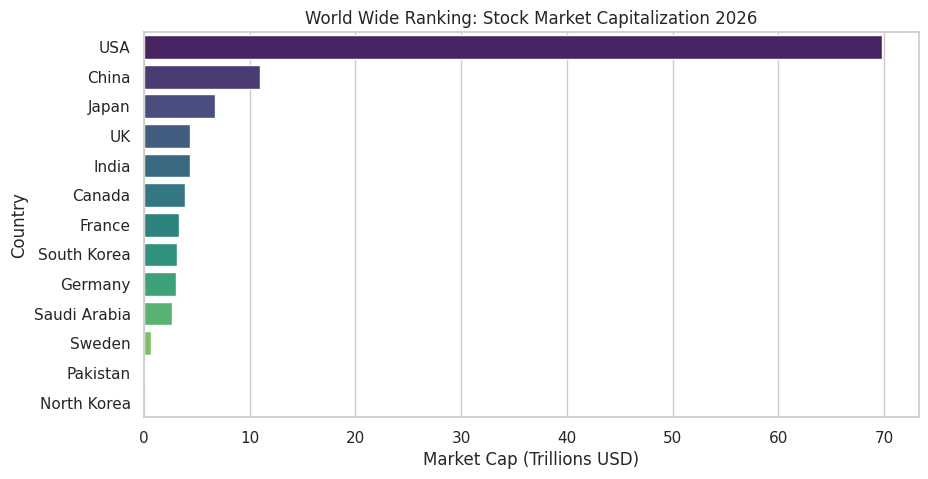

In [33]:
plt.figure(figsize=(10, 5))
sns.barplot(x='Market_Cap_T', y='Country', data=df, palette='viridis')
plt.title('World Wide Ranking: Stock Market Capitalization 2026')
plt.xlabel('Market Cap (Trillions USD)')
plt.show()


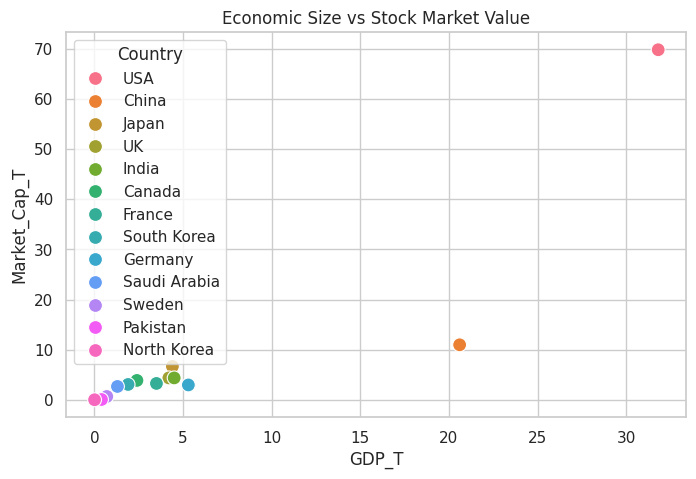

In [34]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='GDP_T', y='Market_Cap_T', data=df, hue='Country', s=100)
plt.title('Economic Size vs Stock Market Value')
plt.grid(True)
plt.show()


In [35]:
# Predicting Market Cap based on GDP
X = df[['GDP_T']].values
y = df['Market_Cap_T'].values


In [36]:

model = LinearRegression()
model.fit(X, y)
predictions = model.predict(X)
print(f"Model Score (R²): {model.score(X, y):.2f}")


Model Score (R²): 0.80


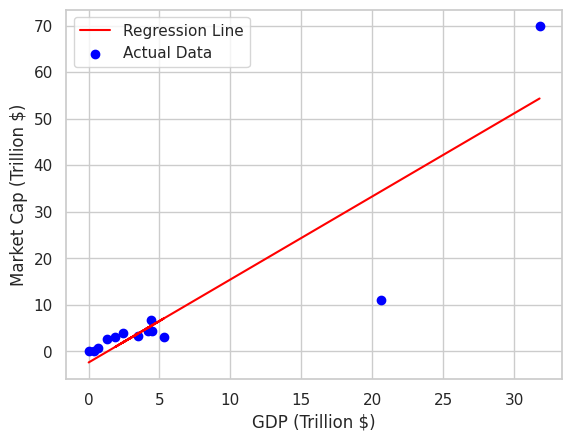

In [37]:
plt.plot(X, predictions, color='red', label='Regression Line')
plt.scatter(X, y, color='blue', label='Actual Data')
plt.xlabel('GDP (Trillion $)')
plt.ylabel('Market Cap (Trillion $)')
plt.legend()
plt.show()


In [41]:
# Final worldwide ranking summary
df['Rank'] = range(1, 14)
print(df[['Rank', 'Country', 'Market_Cap_T', 'Cap_to_GDP_Ratio']])


    Rank       Country  Market_Cap_T  Cap_to_GDP_Ratio
0      1           USA         69.80        219.496855
1      2         China         11.00         53.398058
2      3         Japan          6.70        152.272727
3      4            UK          4.40        104.761905
4      5         India          4.40         97.777778
5      6        Canada          3.90        162.500000
6      7        France          3.30         94.285714
8      8   South Korea          3.10        163.157895
7      9       Germany          3.00         56.603774
9     10  Saudi Arabia          2.70        207.692308
12    11        Sweden          0.70        100.000000
10    12      Pakistan          0.10         25.000000
11    13   North Korea          0.05        500.000000
